# Categorical-to-Continuous Relationships: <br/>Faceted Histograms and Conditional KDE Plots

When visualizing data, there are many possible plots, so it's a good idea to start by thinking about the **goal**.

A common goal in data analysis is: **Does the distribution of a continuous variable change across categories?**

In this notebook, we’ll use the Seaborn `penguins` dataset to compare the distribution of:
- `flipper_length_mm`, a continuous variable

across:
- `species`, a categorical variable

We will use:
- **Faceted histograms**
- **Conditional KDE plots**

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

We will use a default penguins dataset provided by seaborn.

In [2]:
penguins = sns.load_dataset("penguins")
penguins.info()
penguins.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
penguins.shape

(344, 7)

We'll first drop any misisng values in the columns we're going to visualize.

In [4]:
penguins_clean = penguins.dropna(subset=["flipper_length_mm", "species"]) # Drop the missing values.
penguins_clean.shape

(342, 7)

How many rows were dropped?

## Faceted Histograms (One Plot Per Category)

*Facets* are subplots within one figure. Instead of viewing a histogram for the entire distribution of the continuous variable `flipper_length_mm`, we can use facets to view separate distributions for rows that have specific values of `species`. 

A faceted histogram is useful when you want to compare distributions **side-by-side**
without stacking everything on one axis. Here we create one histogram per species.

It's straightforward to create faceted histograms in Seaborn by specifying a categorical variable as the `col` argument (for "column").

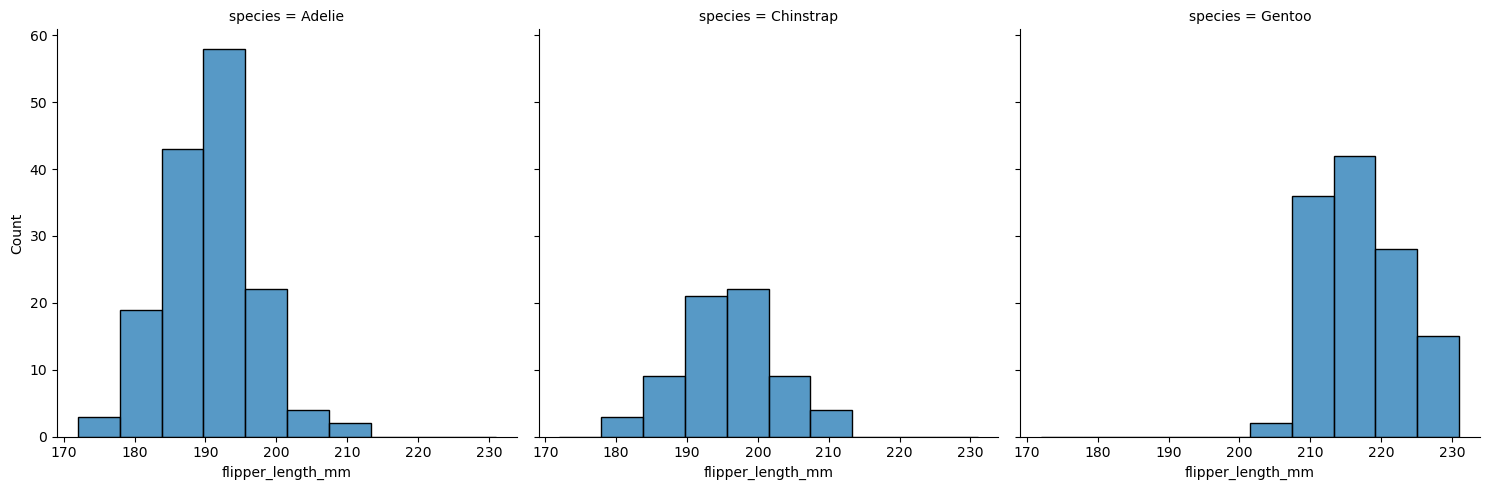

In [5]:
sns.displot(data=penguins_clean, x="flipper_length_mm", col="species", kind="hist")
plt.show()

If you prefer facets as rows instead of columns, you can use the `row` argument:

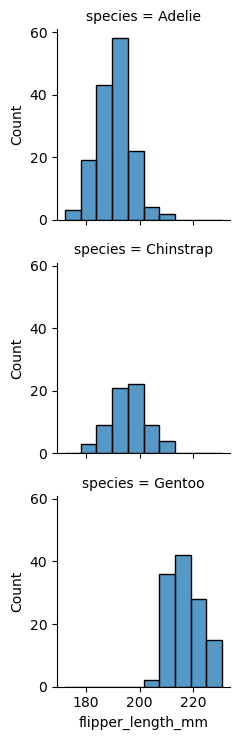

In [6]:
sns.displot(data=penguins_clean, x="flipper_length_mm", row="species", kind="hist", height=2.5)
plt.show()

## Conditional KDE Plots

A kernel density estimate (KDE) plot is a smooth estimate of where values are concentrated. It functions like a histogram to show a distribution of counts across different values, but smoothes out the distinctions between bars.

You can compare how distributions of continuous variables differ across categorical variables by visualizing separate KDE curves for each unique value of a categorical variables. Here we overlay KDE curves to see how distributions of `flipper_length_mm` differ for each `species`:

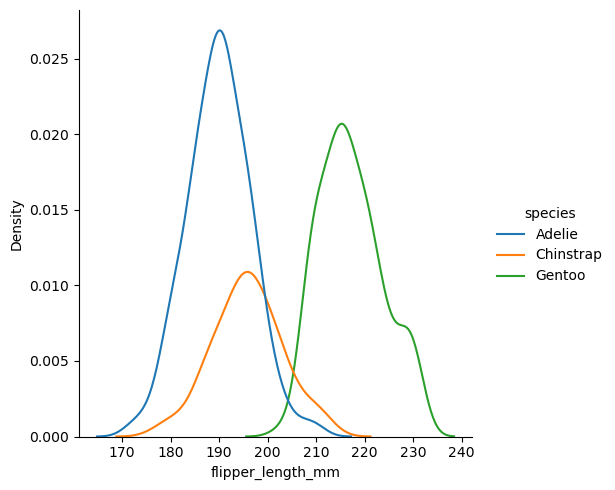

In [7]:
sns.displot(data=penguins_clean, x="flipper_length_mm", hue="species", kind="kde")
plt.show()

## Controlling the Effect of Sample Size

Note that the y-axis no longer shows counts, like histograms do, with KDE plots. Instead it shows "Density", which is an estimate of how many rows (datapoints) are concentrated at different values on the x-axis. 

There may be more rows with some categorical values than others overall, and by default, Seaborn takes this *sample size effect* into account when plotting conditional KDE plots. In the plot above, you can see how the peak for Chinstrap penguins is lower than that of Adelie. That's because:
- The KDE curves are scaled so that the **total area across all groups combined** is 1. Density values reflect this.
- Groups with fewer rows tend to have **smaller curves**, because sample size affects the curve height.

This is useful if your goal is to compare across categorical values while still taking the **overall contribution / frequency across groups** into account. For example, it would address the question:
- "Which species is more common in the dataset, and where are its values concentrated?"

## Removing the Sample Size Effect: `common_norm=False`

Sometimes, you *don’t* want sample size to affect the curve height. If you'd like to compare the concentration of rows across values **regardless of how frequent the categories are compared with other categories**, you can remove the sample size effect and visualize each category's density across values independently.

For example, if your question is:
 "Within each species, where are values concentrated?"

Then set `common_norm=False` to scale each category’s KDE independently (each group’s curve has area 1). This makes the curves are easier to compare in terms of shape, regardless of dataset frequency.

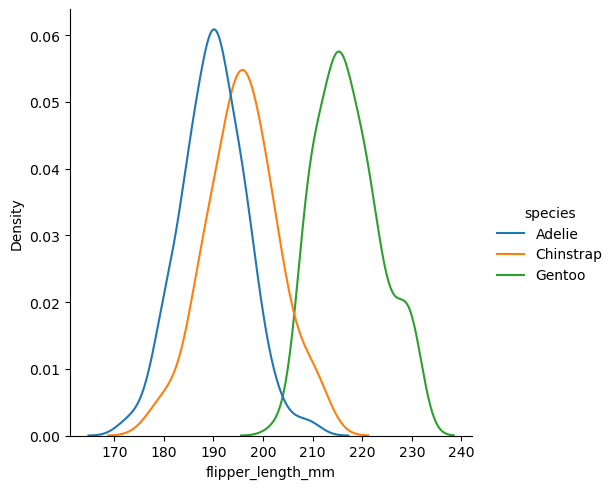

In [8]:
sns.displot(data=penguins_clean, x="flipper_length_mm", hue="species", kind="kde", common_norm=False)
plt.show()

You can see in the conditional KDE plot above that even though there are fewer Chinstrap penguins in the dataset, the peak of its curve is much higher now with the sample size effect removed.

## Key Takeaways

- Faceted histograms help compare distributions without overlap.
- Conditional KDE plots show smooth distribution shapes.
- `common_norm=True` (Seaborn's default value for conditional KDE plots) includes a **sample size effect** (smaller groups → smaller curves).
- `common_norm=False` removes that effect and emphasizes **shape within each category**.